In [42]:
import sys
sys.path.append("..")

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt


print("Imports OK")

Imports OK


In [43]:
# ===============================
# 0. Configuración paths y device
# ===============================
os.makedirs('../outputs', exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA RTX A4000


In [45]:
# ===============================
# 1. Cargar embeddings y labels
# ===============================
print("Cargando datos y embeddings...")
df = pd.read_csv('../data/processed_dataset.csv')
embeddings = torch.load('../outputs/embeddings.pt')  # ESM2 embeddings

X = embeddings.cpu()  # torch tensor
y = torch.tensor(df[['PTM','IPTM']].values, dtype=torch.float32)

print(f"Shape embeddings: {X.shape}")
print(f"Shape labels: {y.shape}")

Cargando datos y embeddings...
Shape embeddings: torch.Size([28800, 480])
Shape labels: torch.Size([28800, 2])


In [46]:
# ===============================
# 2. Split Train/Test
# ===============================

import os
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X.numpy(), y.numpy(), test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

# ===============================
# Guardar fuera del notebook
# ===============================

PROJECT_ROOT = os.path.abspath("..")   # subir desde notebooks → Validador
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

np.save(os.path.join(OUTPUT_DIR, "X_test.npy"), X_test)
np.save(os.path.join(OUTPUT_DIR, "y_test.npy"), y_test)

print("Archivos guardados en:")
print(os.path.join(OUTPUT_DIR, "X_test.npy"))
print(os.path.join(OUTPUT_DIR, "y_test.npy"))

Train size: (23040, 480)
Test size: (5760, 480)
Archivos guardados en:
/home/a01795976/accelerated-drug-design/Validador/outputs/X_test.npy
/home/a01795976/accelerated-drug-design/Validador/outputs/y_test.npy


In [47]:
# ===============================
# 3. Definir modelos
# ===============================

# --- Modelos scikit-learn ---
sklearn_models = {
    "ridge": MultiOutputRegressor(Ridge()),
    "rf": MultiOutputRegressor(RandomForestRegressor(
        n_estimators=200, max_depth=25, n_jobs=-1, random_state=42
    )),
    "mlp": MultiOutputRegressor(MLPRegressor(
        hidden_layer_sizes=(256,128), max_iter=500, random_state=42
    )),
    "xgb": MultiOutputRegressor(XGBRegressor(
        n_estimators=600, learning_rate=0.03, max_depth=8, subsample=0.9,
        colsample_bytree=0.8, tree_method="hist", objective='reg:squarederror',
        random_state=42,  n_jobs=-1
    ))
}

# --- Modelos PyTorch ---
class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim=480):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=8, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

    def forward(self, x):
        return self.encoder(x)

class MLPPredictor(nn.Module):
    def __init__(self, input_dim=480):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,2)
        )

    def forward(self,x):
        return self.model(x)

torch_models = {
    "transformer": TransformerEncoder(embed_dim=X_train.shape[1]).to(device),
    "mlp_torch": MLPPredictor(input_dim=X_train.shape[1]).to(device)
}

In [48]:
# ===============================
# 4. Entrenamiento scikit-learn
# ===============================
trained_models = {}
results = []

for name, model in sklearn_models.items():
    print(f"\n=== Entrenando {name} ===")
    model.fit(X_train, y_train)
    trained_models[name] = model
    joblib.dump(model, f"../outputs/model_{name}.pkl")

    preds = model.predict(X_test)
    r2 = np.corrcoef(y_test.flatten(), preds.flatten())[0,1]**2
    rmse = np.sqrt(np.mean((y_test - preds)**2))

    results.append({"model": name, "R2": r2, "RMSE": rmse})


=== Entrenando ridge ===

=== Entrenando rf ===

=== Entrenando mlp ===

=== Entrenando xgb ===


In [50]:
# ===============================
# 5. Entrenamiento PyTorch
# ===============================
import torch
import torch.nn as nn

def train_torch_model(model, X, y, epochs=20, lr=1e-3, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = model.to(device)
    
    # Convertir a tensores float
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    y_t = torch.tensor(y, dtype=torch.float32).to(device)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(1, epochs+1):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_t)
        
        # outputs debe ser shape [N,2], y_t shape [N,2]
        loss = criterion(outputs, y_t)
        loss.backward()
        optimizer.step()
        
        if epoch % 5 == 0 or epoch==1:
            print(f"Epoch {epoch}/{epochs} - Loss: {loss.item():.6f}")
    
    return model

In [51]:
# ===============================
# 6. Guardar métricas
# ===============================
df_results = pd.DataFrame(results)
df_results.to_csv('../outputs/model_metrics.csv', index=False)
display(df_results)


,model,R2,RMSE
0,ridge,0.916254,0.065756
1,rf,0.967994,0.040762
2,mlp,0.929924,0.060693
3,xgb,0.971264,0.038558


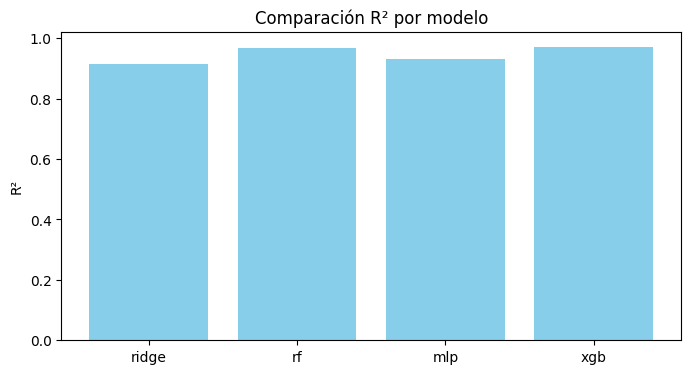

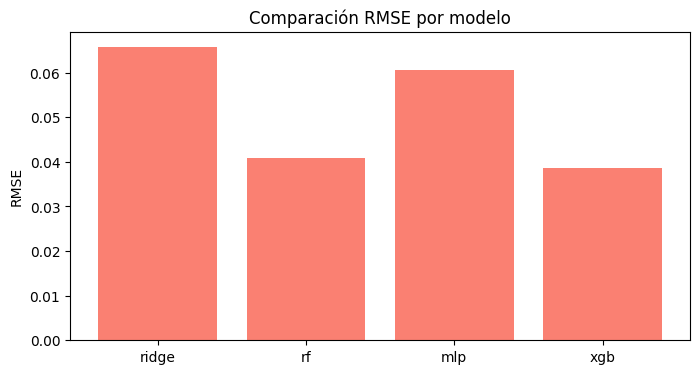

In [52]:
# ===============================
# 7. Graficas
# ===============================
plt.figure(figsize=(8,4))
plt.bar(df_results["model"], df_results["R2"], color='skyblue')
plt.ylabel("R²")
plt.title("Comparación R² por modelo")
plt.show()

plt.figure(figsize=(8,4))
plt.bar(df_results["model"], df_results["RMSE"], color='salmon')
plt.ylabel("RMSE")
plt.title("Comparación RMSE por modelo")
plt.show()